# Occupancy in Smart Buildings

This project develops a binary classification system that predicts whether a room is occupied using environmental sensor readings.

Occupancy detection can support smart-building applications such as automatic lighting, ventilation control, energy optimization, and indoor environment management.

Four classification models are compared:

1. Logistic Regression
2. Support Vector Machine
3. Random Forest
4. Decision Tree

The models are evaluated using validation predictions, probability-based metrics, ROC curves, Precision–Recall curves, and threshold analysis.

In [3]:
#import required libraries
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Matplotlib is building the font cache; this may take a moment.


## 1.Load and Exploar Dataset

The dataset is already provided as two separate files:

- DataTraining.csv which is used for model training and validation.
- DataTest.csv which is kept separate for final model evaluation.

Keeping the provided test file untouched prevents information from the final evaluation data from influencing model selection or threshold tuning.

In [4]:
from pathlib import Path

# Define the local data directory
data_dir = Path("data")

# Load the training and testing datasets
train_df = pd.read_csv(
    data_dir / "DataTraining.csv"
)

test_df = pd.read_csv(
    data_dir / "DataTest.csv"
)

In [5]:
#print datasets shapes
print("Training shape:", train_df.shape)
print("\nTesting shape:", test_df.shape)

#inspect first 5 records
print("\n", train_df.head())

Training shape: (8143, 8)

Testing shape: (9752, 8)

    Unnamed: 0              date  Temperature  Humidity  Light     CO2  \
0           1  04-02-2015 17:51        23.18   27.2720  426.0  721.25   
1           2  04-02-2015 17:51        23.15   27.2675  429.5  714.00   
2           3  04-02-2015 17:53        23.15   27.2450  426.0  713.50   
3           4  04-02-2015 17:54        23.15   27.2000  426.0  708.25   
4           5  04-02-2015 17:55        23.10   27.2000  426.0  704.50   

   HumidityRatio  Occupancy  
0       0.004793          1  
1       0.004783          1  
2       0.004779          1  
3       0.004772          1  
4       0.004757          1  


In [6]:
#print datasets information

print("Training information:")
train_df.info()

print("\nTesting information:")
test_df.info()


Training information:
<class 'pandas.DataFrame'>
RangeIndex: 8143 entries, 0 to 8142
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     8143 non-null   int64  
 1   date           8143 non-null   str    
 2   Temperature    8143 non-null   float64
 3   Humidity       8143 non-null   float64
 4   Light          8143 non-null   float64
 5   CO2            8143 non-null   float64
 6   HumidityRatio  8143 non-null   float64
 7   Occupancy      8143 non-null   int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 509.1 KB

Testing information:
<class 'pandas.DataFrame'>
RangeIndex: 9752 entries, 0 to 9751
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     9752 non-null   int64  
 1   date           9752 non-null   str    
 2   Temperature    9752 non-null   float64
 3   Humidity       9752 non-null   float64
 4

In [7]:
# check for missing or duplicated values in datasets

print("Training missing values:", train_df.isnull().sum())
print("--"*25)
print("Testing missing values:",test_df.isnull().sum())
print("--"*25)
print("Training duplicated rows:", train_df.duplicated().sum())
print("Testing duplicated rows:", test_df.duplicated().sum())

Training missing values: Unnamed: 0       0
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64
--------------------------------------------------
Testing missing values: Unnamed: 0       0
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64
--------------------------------------------------
Training duplicated rows: 0
Testing duplicated rows: 0


In [8]:
#drop the additional column "Unnamed: 0" and checking
train_df = train_df.drop(columns=["Unnamed: 0"])
test_df = test_df.drop(columns=["Unnamed: 0"])

print("Training columns:",train_df.columns.tolist())
print("\nTraining columns:",test_df.columns.tolist())


Training columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']

Training columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']


In [9]:
#set the target of classification
target = "Occupancy" #where 1 = Occupied and 0 = Not Occupied

In [10]:
#Analyze the classes distributions

# check the target "Occupancy" distribution in the training data

occupancy_counts = train_df["Occupancy"].value_counts()
occupancy_percentages = (train_df["Occupancy"].value_counts(normalize=True).mul(100).round(2))

print("Class counts:" , occupancy_counts)
print("\n\nClass percentages:" , occupancy_percentages)


Class counts: Occupancy
0    6414
1    1729
Name: count, dtype: int64


Class percentages: Occupancy
0    78.77
1    21.23
Name: proportion, dtype: float64


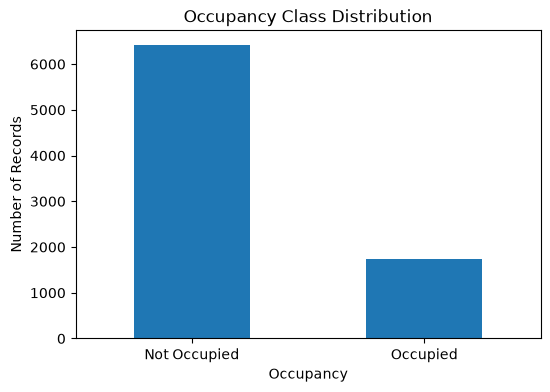

In [11]:
# Visualize the target "Occupancy" distribution

occupancy_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Occupancy Class Distribution")
plt.xlabel("Occupancy")
plt.ylabel("Number of Records")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Occupied", "Occupied"],
    rotation=0
)
plt.show()


- Around 78.77% not-occupied records and 21.23% occupied records,this indicates moderate class imbalance so later we will use class_weight="balanced" during training to help with this challenge

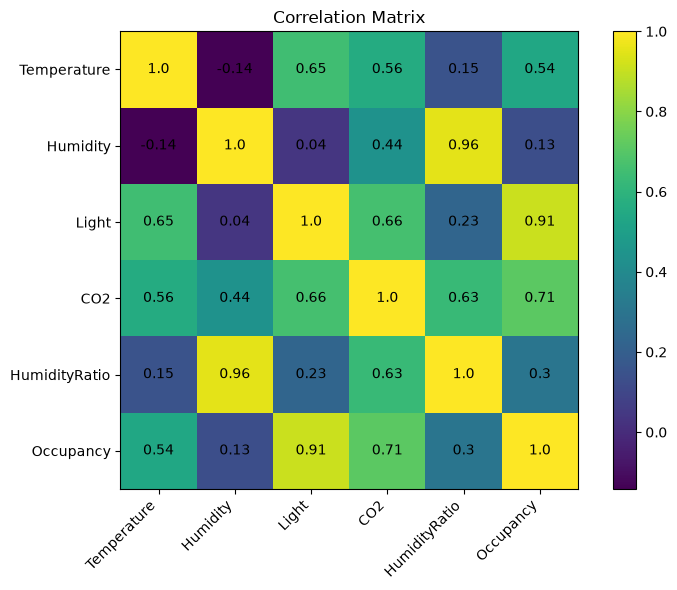

In [12]:
#using correlation matrix to examine the relationships between the numerical sensor features and the occupancy target

# Select numerical features --> All features are numeric except for time (object)
numeric_columns = [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio",
    "Occupancy"
]

# Calculate correlation through matrix
correlation_matrix = train_df[numeric_columns].corr()

# Draw the correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


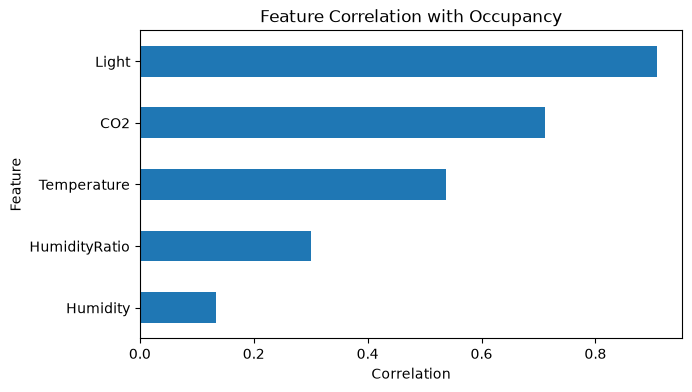

In [13]:
# Show the correlation with target Occupancy only

occupancy_correlation = (correlation_matrix["Occupancy"].drop("Occupancy").sort_values())

occupancy_correlation.plot(
    kind="barh",
    figsize=(7, 4)
)

plt.title("Feature Correlation with Occupancy")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

- Light is the strongest individual predictor, followed by CO2 and temperature
- Also there is very strong correlation of approximately 0.96 between Humidity and HumidityRatio this indicates that both features contain highly similar information

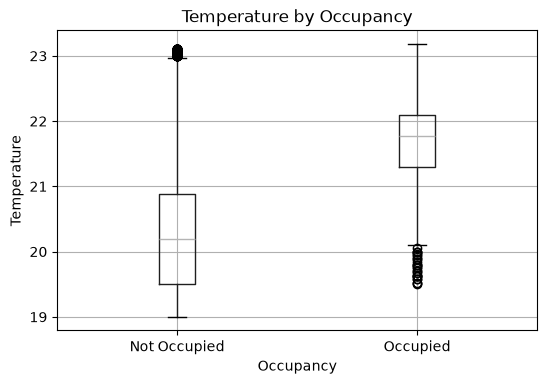

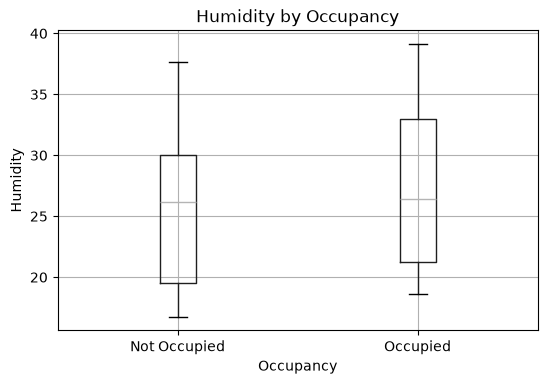

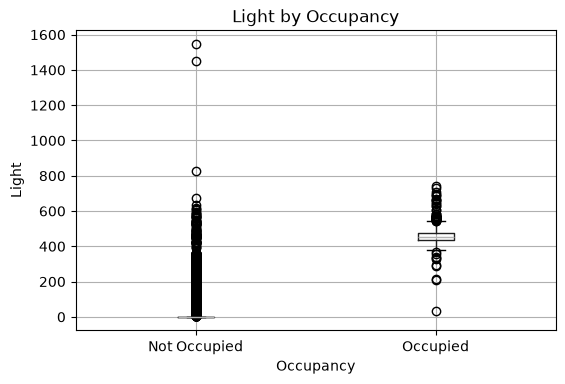

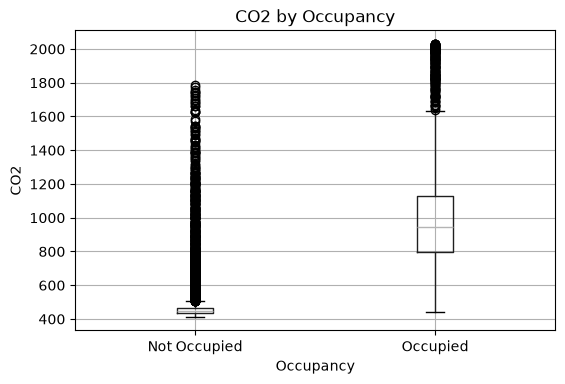

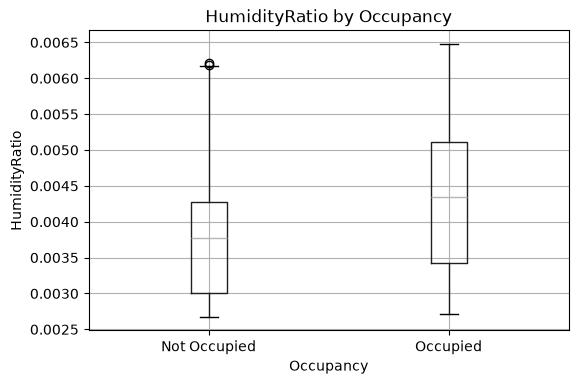

In [14]:
# visualize sensor features by Occupancy using Boxplots --> to compare sensor readings when the room is occupied and not occupied

sensor_features = [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio"
] #excluding the target

for feature in sensor_features:
    train_df.boxplot(
        column=feature,
        by="Occupancy",
        figsize=(6, 4)
    )

    plt.title(f"{feature} by Occupancy")
    plt.suptitle("")
    plt.xlabel("Occupancy")
    plt.ylabel(feature)
    plt.xticks(
        ticks=[1, 2],
        labels=["Not Occupied", "Occupied"]
    )
    plt.show()

  #even that the box visualization show slightly outliers

**Boxplots visuals show that:**
- Light levels are higher when the room is occupied
- CO2 concentration is much higher when people are present
- Temperature tends to be higher in occupied observations.
- Humidity shows overlap between the two classes.
- HumidityRatio provides some separation, but less than Light or CO2.

Since we are dealing with sensors data values outside the boxplot may represent valid sensor conditions, such as lights remaining on when the room is empty or CO2 remaining elevated after occupants leave so we will keep them.

##2. Feature selection and dataset splitting

**Features evaluation and Selection**

The final model inputs would be:

- Temperature
- Light
- CO2
- HumidityRatio

- We exclude Humidity feature because it has a weak relationship with the target and is highly correlated with HumidityRatio so we do not have to keep both of them.  

- We exclude date column too because it is not a direct sensor measurement.

Note that the excluded columns are not deleted from the datasets, we only pass the selected features to the models.

In [15]:
#Train-Validate splitting

features = ["Temperature","Light","CO2","HumidityRatio"]
target = "Occupancy"

X = train_df[features]
y = train_df[target]

# Preserve class proportions in training and validation sets using stratify=y
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Keep the test file unchanged for final evaluation
X_test = test_df[features]
y_test = test_df[target]

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Testing shape:", X_test.shape)

Training shape: (6514, 4)
Validation shape: (1629, 4)
Testing shape: (9752, 4)


**Training, Validation, and Testing Sets**

- The testing file remains unchanged for final evaluation.

- The training file is divided into:

   1. 80% training set
   2. 20% validation set

A stratified split stratify=y is used to preserve the original occupancy-class proportions in both subsets.

random_state=42 ensures that the same records are selected every time the notebook is executed, making the experiment reproducible.


In [16]:
# Check class distribution in each datasetto ensure that both occupancy classes are represented

datasets = {
    "Training": y_train,
    "Validation": y_validation,
    "Testing": y_test
}

for name, target_data in datasets.items():
    print("--"*20)
    print(f"{name} class counts:")
    print(target_data.value_counts())

    print(f"{name} class percentages:")
    print(
        target_data.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

----------------------------------------
Training class counts:
Occupancy
0    5131
1    1383
Name: count, dtype: int64
Training class percentages:
Occupancy
0    78.77
1    21.23
Name: proportion, dtype: float64
----------------------------------------
Validation class counts:
Occupancy
0    1283
1     346
Name: count, dtype: int64
Validation class percentages:
Occupancy
0    78.76
1    21.24
Name: proportion, dtype: float64
----------------------------------------
Testing class counts:
Occupancy
0    7703
1    2049
Name: count, dtype: int64
Testing class percentages:
Occupancy
0    78.99
1    21.01
Name: proportion, dtype: float64


## 3. Model Pipelines


In [17]:
# Create one pipeline for classification models with class_weight="balanced"
# class_weight="balanced" gives more importance to the minority class

models = {

    # Logistic Regression
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    # Support Vector Machine
    "Support Vector Machine": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,  # Required to generate prediction probabilities
            random_state=42
        ))
    ]),

    # Random Forest
    "Random Forest": Pipeline(steps=[
        ("scaler", "passthrough"),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    #Decision Tree
    "Decision Tree": Pipeline(steps=[
        ("scaler", "passthrough"),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ])
}



**StandardScaler** is applied to:

- Logistic Regression
- Support Vector Machine

These models are sensitive to differences in feature scales.

Scaling is **not** required for:

- Random Forest
- Decision Tree

All models use **class_weight="balanced"** to give more importance to the minority occupied class without changing the number of training records.

## 4. Model train and generate validation predictions probabilities

In [18]:
# Train all models and generate validation prediction probabilities

validation_probabilities = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)

    # Probability that each validation record belongs to class 1 (Occupied)
    validation_probabilities[model_name] = pipeline.predict_proba(X_validation)[:, 1]

    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
Support Vector Machine trained successfully.


/Users/joudalrubaish/Tuwaiq-AI /Smart_Building/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Random Forest trained successfully.
Decision Tree trained successfully.


## 5. Model Evaluation

The classification threshold converts a predicted probability into a class:

- Probability below the threshold → Not Occupied (0)
- Probability equal to or above the threshold → Occupied (1)


In [19]:
# Evaluate models using multiple classification thresholds and compare the default threshold (0.50) with the optimal threshold.

threshold_values = np.arange(0.10, 0.91, 0.05)
threshold_results = []
optimal_thresholds = {}

for model_name, y_probability in validation_probabilities.items():
    model_rows = []

    for threshold in threshold_values:
        y_prediction = (y_probability >= threshold).astype(int)

        row = {
            "Model": model_name,
            "Threshold": round(float(threshold), 2),
            "Accuracy": accuracy_score(y_validation, y_prediction),
            "Precision": precision_score(y_validation, y_prediction, zero_division=0),
            "Recall": recall_score(y_validation, y_prediction, zero_division=0),
            "F1-Score": f1_score(y_validation, y_prediction, zero_division=0)
        }

        threshold_results.append(row)
        model_rows.append(row)

    # Select the threshold with the highest validation F1-score.
    # In case of a tie, select the threshold closest to 0.50.
    optimal_row = max(
        model_rows,
        key=lambda row: (row["F1-Score"], -abs(row["Threshold"] - 0.50))
    )
    optimal_thresholds[model_name] = optimal_row["Threshold"]

threshold_results_df = pd.DataFrame(threshold_results)

# Display all threshold results
display(
    threshold_results_df.round(4)
    .sort_values(["Model", "Threshold"])
    .reset_index(drop=True)
)

# Compare default and optimal thresholds
comparison_rows = []

for model_name, y_probability in validation_probabilities.items():
    optimal_threshold = optimal_thresholds[model_name]

    for threshold_type, threshold in [
        ("Default", 0.50),
        ("Optimal", optimal_threshold)
    ]:
        y_prediction = (y_probability >= threshold).astype(int)

        comparison_rows.append({
            "Model": model_name,
            "Threshold Type": threshold_type,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_validation, y_prediction),
            "Precision": precision_score(y_validation, y_prediction, zero_division=0),
            "Recall": recall_score(y_validation, y_prediction, zero_division=0),
            "F1-Score": f1_score(y_validation, y_prediction, zero_division=0)
        })

threshold_comparison_df = pd.DataFrame(comparison_rows)

print("\nDefault Threshold vs Optimal Threshold")
display(threshold_comparison_df.round(4))



,Model,Threshold,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.10,0.9865,0.9402,1.0000,0.9692
1,Decision Tree,0.15,0.9902,0.9583,0.9971,0.9773
2,Decision Tree,0.20,0.9902,0.9583,0.9971,0.9773
3,Decision Tree,0.25,0.9902,0.9583,0.9971,0.9773
4,Decision Tree,0.30,0.9902,0.9583,0.9971,0.9773
...,...,...,...,...,...,...
63,Support Vector Machine,0.70,0.9877,0.9454,1.0000,0.9719
64,Support Vector Machine,0.75,0.9877,0.9454,1.0000,0.9719
65,Support Vector Machine,0.80,0.9877,0.9454,1.0000,0.9719
66,Support Vector Machine,0.85,0.9871,0.9452,0.9971,0.9705



Default Threshold vs Optimal Threshold


,Model,Threshold Type,Threshold,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Default,0.50,0.9865,0.9402,1.0000,0.9692
1,Logistic Regression,Optimal,0.55,0.9871,0.9428,1.0000,0.9705
2,Support Vector Machine,Default,0.50,0.9877,0.9454,1.0000,0.9719
3,Support Vector Machine,Optimal,0.50,0.9877,0.9454,1.0000,0.9719
4,Random Forest,Default,0.50,0.9926,0.9691,0.9971,0.9829
5,Random Forest,Optimal,0.75,0.9963,0.9857,0.9971,0.9914
6,Decision Tree,Default,0.50,0.9932,0.9718,0.9971,0.9843
7,Decision Tree,Optimal,0.50,0.9932,0.9718,0.9971,0.9843



Logistic Regression - Default Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       1.00      0.98      0.99      1283
    Occupied       0.94      1.00      0.97       346

    accuracy                           0.99      1629
   macro avg       0.97      0.99      0.98      1629
weighted avg       0.99      0.99      0.99      1629



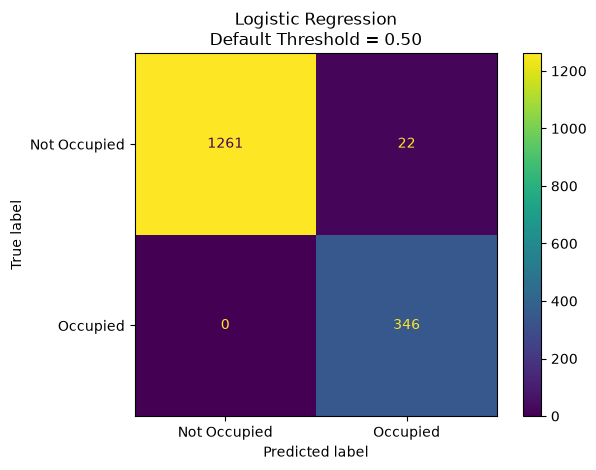


Logistic Regression - Optimal Threshold: 0.55
              precision    recall  f1-score   support

Not Occupied       1.00      0.98      0.99      1283
    Occupied       0.94      1.00      0.97       346

    accuracy                           0.99      1629
   macro avg       0.97      0.99      0.98      1629
weighted avg       0.99      0.99      0.99      1629



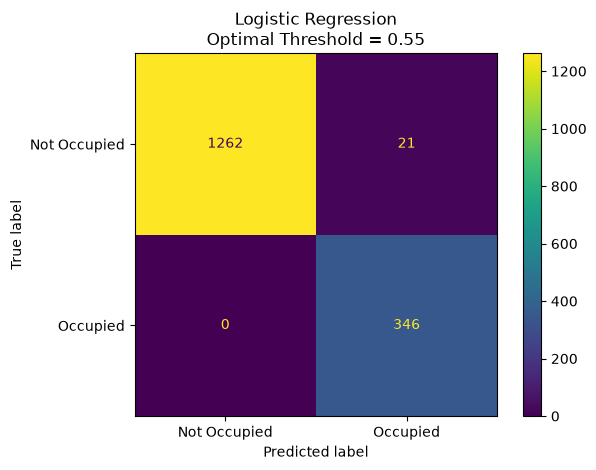


Support Vector Machine - Default Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       1.00      0.98      0.99      1283
    Occupied       0.95      1.00      0.97       346

    accuracy                           0.99      1629
   macro avg       0.97      0.99      0.98      1629
weighted avg       0.99      0.99      0.99      1629



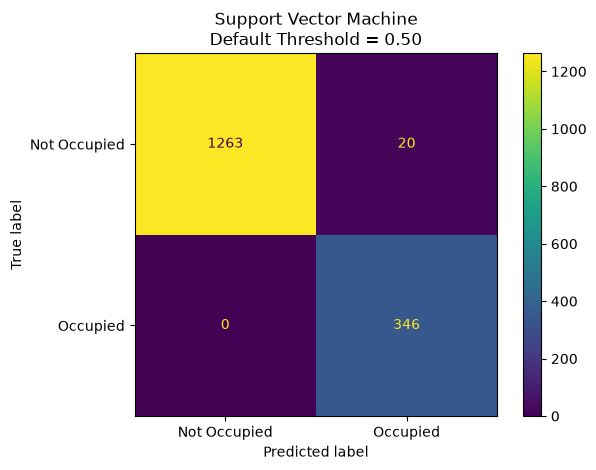


Support Vector Machine - Optimal Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       1.00      0.98      0.99      1283
    Occupied       0.95      1.00      0.97       346

    accuracy                           0.99      1629
   macro avg       0.97      0.99      0.98      1629
weighted avg       0.99      0.99      0.99      1629



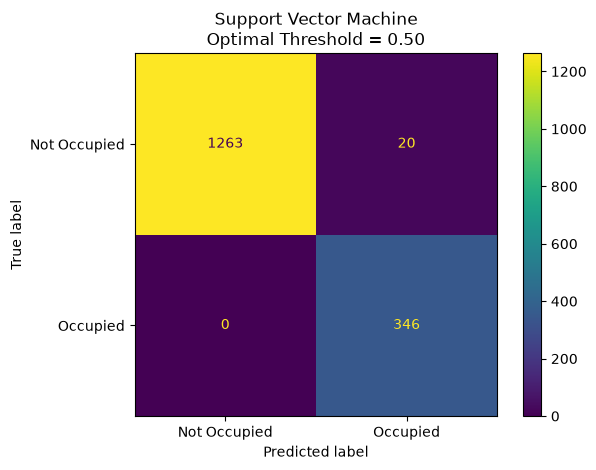


Random Forest - Default Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       1.00      0.99      1.00      1283
    Occupied       0.97      1.00      0.98       346

    accuracy                           0.99      1629
   macro avg       0.98      0.99      0.99      1629
weighted avg       0.99      0.99      0.99      1629



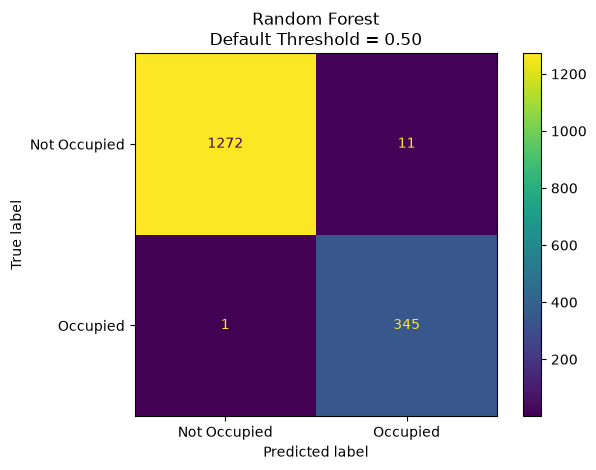


Random Forest - Optimal Threshold: 0.75
              precision    recall  f1-score   support

Not Occupied       1.00      1.00      1.00      1283
    Occupied       0.99      1.00      0.99       346

    accuracy                           1.00      1629
   macro avg       0.99      1.00      0.99      1629
weighted avg       1.00      1.00      1.00      1629



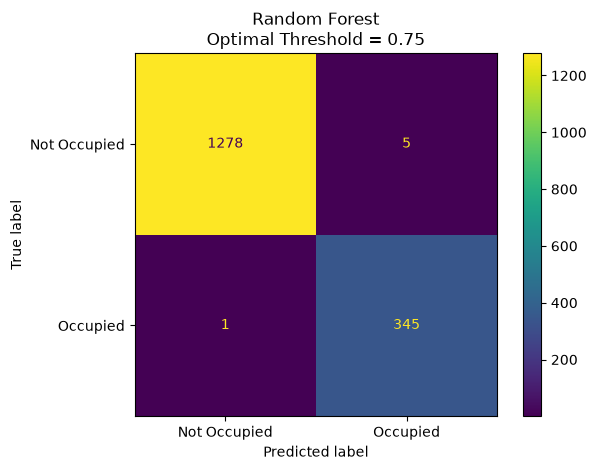


Decision Tree - Default Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       1.00      0.99      1.00      1283
    Occupied       0.97      1.00      0.98       346

    accuracy                           0.99      1629
   macro avg       0.99      0.99      0.99      1629
weighted avg       0.99      0.99      0.99      1629



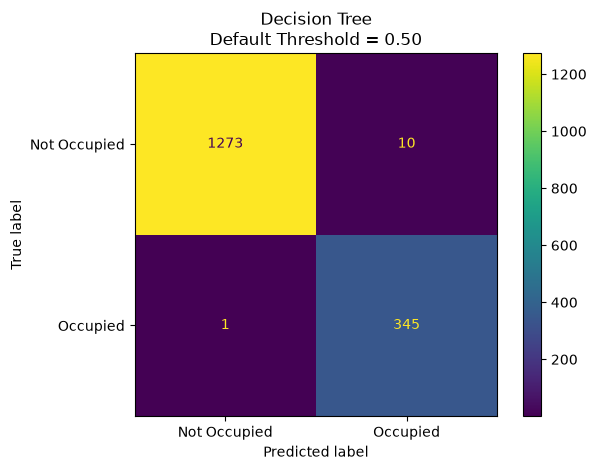


Decision Tree - Optimal Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       1.00      0.99      1.00      1283
    Occupied       0.97      1.00      0.98       346

    accuracy                           0.99      1629
   macro avg       0.99      0.99      0.99      1629
weighted avg       0.99      0.99      0.99      1629



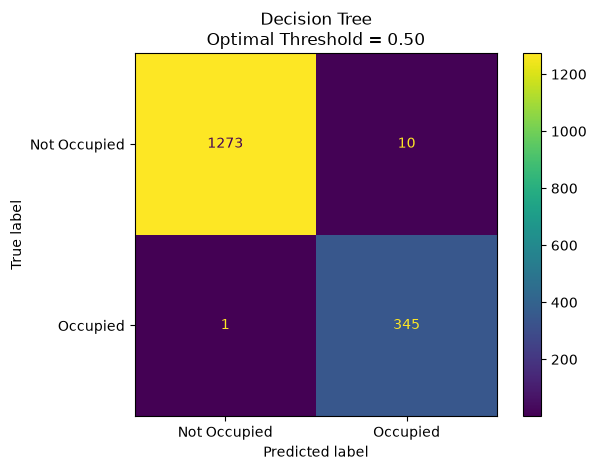

In [20]:
# Generate a Classification Report and Confusion Matrix for both the default and optimal thresholds.

for model_name, y_probability in validation_probabilities.items():
    optimal_threshold = optimal_thresholds[model_name]

    for threshold_type, threshold in [
        ("Default Threshold", 0.50),
        ("Optimal Threshold", optimal_threshold)
    ]:
        y_prediction = (y_probability >= threshold).astype(int)

        print("\n" + "=" * 75)
        print(f"{model_name} - {threshold_type}: {threshold:.2f}")
        print("=" * 75)
        print(
            classification_report(
                y_validation,
                y_prediction,
                target_names=["Not Occupied", "Occupied"],
                zero_division=0
            )
        )

        cm = confusion_matrix(y_validation, y_prediction)

        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Not Occupied", "Occupied"]
        ).plot(values_format="d")

        plt.title(f"{model_name}\n{threshold_type} = {threshold:.2f}")
        plt.tight_layout()
        plt.show()


**Threshold Findings**

The validation-selected threshold of 0.65 improved precision by reducing false-positive occupancy predictions. However, on the independent test dataset, it reduced occupied-class recall and F1-score compared with the default threshold of 0.50.

This indicates that the optimal validation threshold did not generalize perfectly to the separate test period. The final operational threshold should therefore be selected according to the application objective. A threshold of 0.50 is preferable when detecting occupied rooms is the priority, while 0.65 is preferable when reducing false occupancy alerts is more important.

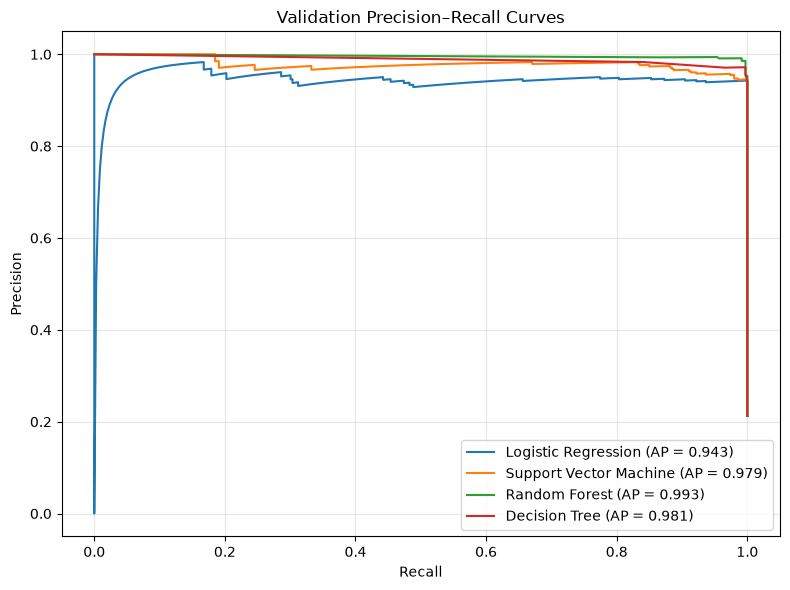

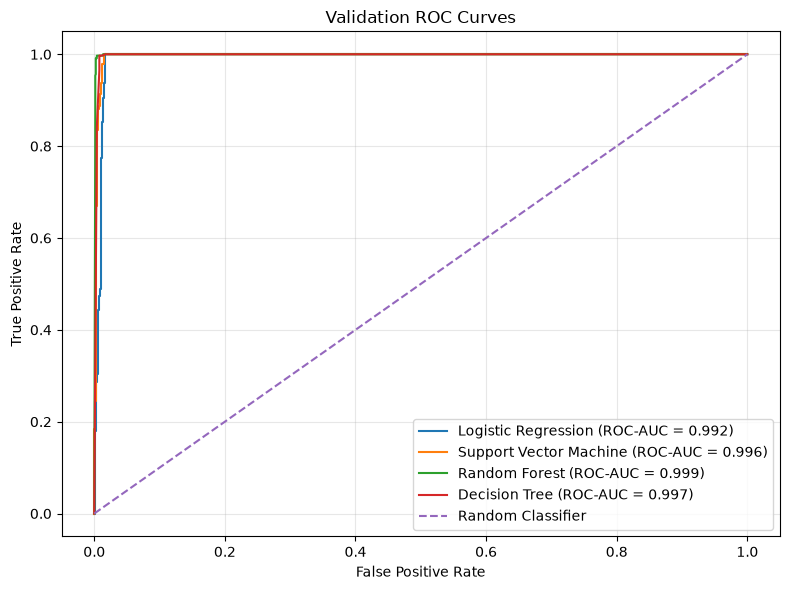

In [21]:
# Generate Precision–Recall and ROC curves for all models.

plt.figure(figsize=(8, 6))

for model_name, y_probability in validation_probabilities.items():
    precision_values, recall_values, _ = precision_recall_curve(
        y_validation,
        y_probability
    )
    average_precision = average_precision_score(
        y_validation,
        y_probability
    )

    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (AP = {average_precision:.3f})"
    )

plt.title("Validation Precision–Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))

for model_name, y_probability in validation_probabilities.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_validation,
        y_probability
    )
    roc_auc = roc_auc_score(y_validation, y_probability)

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (ROC-AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("Validation ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# Summarize probability-based validation performance
# and identify the best model according to optimal-threshold F1-score.

model_summary_rows = []

for model_name, y_probability in validation_probabilities.items():
    optimal_threshold = optimal_thresholds[model_name]
    optimal_prediction = (y_probability >= optimal_threshold).astype(int)

    model_summary_rows.append({
        "Model": model_name,
        "Optimal Threshold": optimal_threshold,
        "Optimal F1-Score": f1_score(
            y_validation,
            optimal_prediction,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_validation, y_probability),
        "Average Precision": average_precision_score(
            y_validation,
            y_probability
        )
    })

model_summary_df = (
    pd.DataFrame(model_summary_rows)
    .sort_values("Optimal F1-Score", ascending=False)
    .reset_index(drop=True)
)

display(model_summary_df.round(4))

best_model_name = model_summary_df.loc[0, "Model"]
best_threshold = model_summary_df.loc[0, "Optimal Threshold"]

print(f"Best validation model: {best_model_name}")
print(f"Selected optimal threshold: {best_threshold:.2f}")


,Model,Optimal Threshold,Optimal F1-Score,ROC-AUC,Average Precision
0,Random Forest,0.75,0.9914,0.9990,0.9932
1,Decision Tree,0.50,0.9843,0.9974,0.9812
2,Support Vector Machine,0.50,0.9719,0.9964,0.9788
3,Logistic Regression,0.55,0.9705,0.9921,0.9434


Best validation model: Random Forest
Selected optimal threshold: 0.75



Final Test Results - Random Forest
Default Threshold: 0.50
              precision    recall  f1-score   support

Not Occupied       0.99      0.95      0.97      7703
    Occupied       0.85      0.97      0.90      2049

    accuracy                           0.96      9752
   macro avg       0.92      0.96      0.94      9752
weighted avg       0.96      0.96      0.96      9752



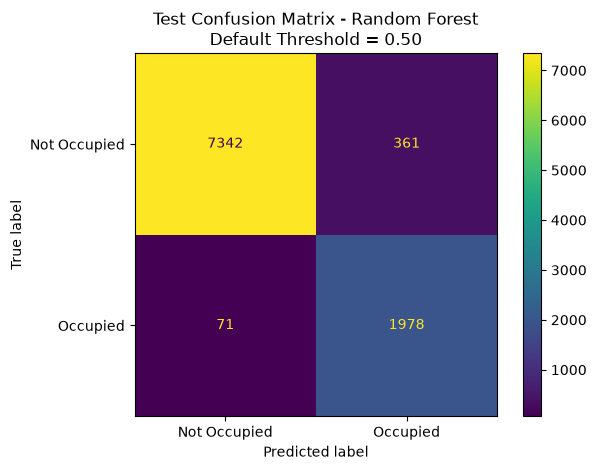


Final Test Results - Random Forest
Selected Optimal Threshold: 0.75
              precision    recall  f1-score   support

Not Occupied       0.96      0.98      0.97      7703
    Occupied       0.91      0.83      0.87      2049

    accuracy                           0.95      9752
   macro avg       0.93      0.90      0.92      9752
weighted avg       0.95      0.95      0.95      9752



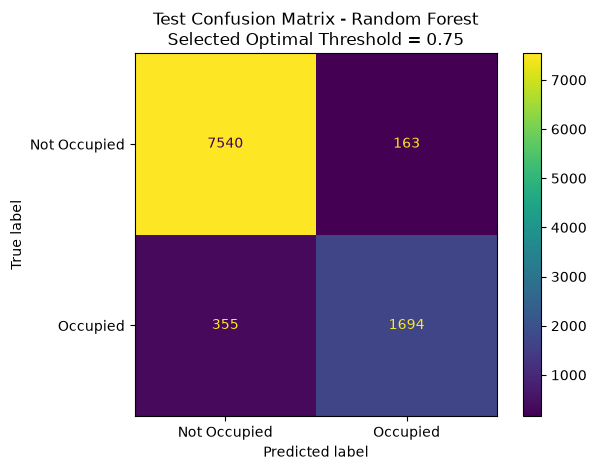

Test ROC-AUC: 0.9900
Test Average Precision: 0.9604


In [23]:
# Final evaluation on the untouched test set.
# The model and threshold were selected using validation data only.

best_model = models[best_model_name]
test_probability = best_model.predict_proba(X_test)[:, 1]

test_default_prediction = (test_probability >= 0.50).astype(int)
test_optimal_prediction = (test_probability >= best_threshold).astype(int)

for threshold_type, threshold, y_prediction in [
    ("Default Threshold", 0.50, test_default_prediction),
    ("Selected Optimal Threshold", best_threshold, test_optimal_prediction)
]:
    print("\n" + "=" * 75)
    print(f"Final Test Results - {best_model_name}")
    print(f"{threshold_type}: {threshold:.2f}")
    print("=" * 75)
    print(
        classification_report(
            y_test,
            y_prediction,
            target_names=["Not Occupied", "Occupied"],
            zero_division=0
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_prediction),
        display_labels=["Not Occupied", "Occupied"]
    ).plot(values_format="d")

    plt.title(
        f"Test Confusion Matrix - {best_model_name}\n"
        f"{threshold_type} = {threshold:.2f}"
    )
    plt.tight_layout()
    plt.show()

print(f"Test ROC-AUC: {roc_auc_score(y_test, test_probability):.4f}")
print(
    "Test Average Precision:",
    f"{average_precision_score(y_test, test_probability):.4f}"
)


## 6. LLM Integration

In [24]:
import os
from dotenv import load_dotenv
from google import genai

# Load environment variables from .env
load_dotenv()

gemini_key = os.getenv("GEMINI_API_KEY")

if not gemini_key:
    raise ValueError(
        "GEMINI_API_KEY was not found in the .env file."
    )

# Initialize the Gemini client
client = genai.Client(api_key=gemini_key)

def call_llm(prompt: str) -> str:
    """Send a prompt to Gemini and return the generated response."""

    response = client.models.generate_content(
        model="models/gemini-flash-latest",
        contents=prompt
    )

    return response.text

# Dynamic data from the trained ML model test predictions
sample_idx = 0
sample_temp = X_test.iloc[sample_idx]['Temperature']
sample_light = X_test.iloc[sample_idx]['Light']
sample_co2 = X_test.iloc[sample_idx]['CO2']
sample_hum_ratio = X_test.iloc[sample_idx]['HumidityRatio']
model_prediction_str = "Occupied" if test_optimal_prediction[sample_idx] == 1 else "Not Occupied"
model_prob = test_probability[sample_idx]


#Zero-Shot Prompting
print("\n" + "=" * 30)
print("Zero-Shot Prompting")
print("=" * 30)

zero_shot_prompt = f"""
You are an AI assistant for a smart building management system.
Summarize the current room condition for a building operator in 2 clear sentences:

- Temperature: {sample_temp:.1f} °C
- Light: {sample_light:.1f} Lux
- CO2 Concentration: {sample_co2:.1f} ppm
- Humidity Ratio: {sample_hum_ratio:.5f}
- ML Prediction: {model_prediction_str} (Confidence: {model_prob * 100:.1f}%)
"""

print(call_llm(zero_shot_prompt))

# Few-Shot Prompting
print("\n" + "=" * 30)
print("Few-Shot Prompting")
print("=" * 30)

few_shot_prompt = f"""
You are an automated HVAC and lighting controller parser. Convert room data into JSON format.

Example 1:
Input: Light = 0 Lux, CO2 = 410 ppm, Occupancy = Not Occupied
Output: {{\"lights\": \"OFF\", \"hvac_mode\": \"ECO\", \"ventilation\": \"MINIMAL\"}}

Example 2:
Input: Light = 480 Lux, CO2 = 1050 ppm, Occupancy = Occupied
Output: {{\"lights\": \"ON\", \"hvac_mode\": \"COMFORT\", \"ventilation\": \"HIGH\"}}

Input: Light = {sample_light:.1f} Lux, CO2 = {sample_co2:.1f} ppm, Occupancy = {model_prediction_str}
Output:
"""

print(call_llm(few_shot_prompt))

# Reasoning / Chain-of-Thought Prompting
print("\n" + "=" * 30)
print("Reasoning Prompting")
print("=" * 30)

cot_prompt = """
You are a smart building diagnostic engine. Analyze this conflicting sensor scenario step-by-step:

Sensors:
- Light: 0.0 Lux (Pitch dark)
- CO2: 1100.0 ppm (Significantly elevated)
- Temperature: 22.5 °C
- ML Model Output: Occupied (Probability: 88%)

Instructions:
1. Step 1 (Reasoning): Explain why CO2 might be high when Light is 0 Lux (e.g., projector presentation in a dark room vs sensor fault).
2. Step 2 (Risk Assessment): What happens if we shut off air conditioning assuming the room is empty?
3. Step 3 (Recommendation): State the final decision for the HVAC system.
"""

print(call_llm(cot_prompt))


Zero-Shot Prompting
The room is confirmed to be occupied, maintaining comfortable ambient conditions with a temperature of 21.8 °C and adequate lighting at 437.3 Lux. However, the CO2 concentration is slightly elevated at 1029.7 ppm alongside a humidity ratio of 0.00502, indicating that a minor increase in ventilation may be beneficial.

Few-Shot Prompting
{"lights": "ON", "hvac_mode": "COMFORT", "ventilation": "HIGH"}

Reasoning Prompting
Here is the step-by-step diagnostic analysis for the conflicting sensor inputs:

---

### **Step 1: Reasoning**
There are two primary hypotheses for why the CO2 level is high (1100.0 ppm) despite the light sensor reading 0.0 Lux:

1. **Occupied Darkened Room (Physical Explanation):**
   * **Projector/Presentation Mode:** Occupants may be watching a presentation, movie, or slideshow with overhead lights completely turned off.
   * **Rest/Sleep Area:** The space might be a rest room, lactation room, or night-shift break area where occupants are sleepi

## Project Findings and Limitations

- Random Forest achieved the strongest validation performance among the four classifiers, with an optimal validation F1-score of 0.9914 and ROC-AUC of 0.9993.

- The independent test ROC-AUC of 0.9924 confirms that the model maintains strong discrimination on unseen data. Light was the strongest individual predictor of occupancy, followed by CO2 and temperature.

- The validation-selected threshold of 0.65 increased test precision but reduced recall compared with the default threshold of 0.50. Therefore, the operational threshold should depend on whether the smart-building system prioritizes detecting occupied rooms or reducing false occupancy alerts.

- The training file was divided using a random stratified split. Because sensor records are sequential, nearby observations may be similar, which may make validation results slightly optimistic. The separate testing file provides a more realistic evaluation of generalization.

- The LLM component does not replace the machine-learning classifier, it is convrted into human-readable explanation to summarize model outputs, produce structured building-control recommendations, and demonstrate zero-shot, few-shot, and reasoning prompting.

    1. Zero-shot prompting summarizes the sensor condition without examples.

    2. Few-shot prompting uses examples to generate a structured control response.
    3. Reasoning prompting examines a conflicting sensor scenario and recommends a cautious.
